In [153]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [154]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [155]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Read the file and prepare data for SVR

In [156]:
file_csv = '../../../data/phen/original/obregon_phenotypic_original_151617.csv'
df = pd.read_csv(file_csv, header=0)
df.head()

,TGW,HI,BM,NDVI_VG1,NDVI_VG2,NDVI_VG3,NDVI_VG4,NDVI_VG,NDVI_GF1,NDVI_GF2,...,NDVI_UAV_1,NDVI_UAV_2,NDVI_UAV_3,NDVI_UAV_4,NDVI_UAV_5,CT_UAV_1,CT_UAV_2,CT_UAV_3,CT_UAV_4,YLD
0,40.510542,0.493706,1252.841830,0.171286,0.176257,0.375381,0.757965,0.444839,0.776698,0.744168,...,0.499727,0.458816,0.659201,0.754407,0.873936,25.451605,24.184386,24.083716,31.700124,617.4453
1,37.094174,0.492329,1403.919849,0.170764,0.214652,0.409778,0.782313,0.469060,0.770800,0.720762,...,0.486031,0.499782,0.693321,0.777470,0.878137,25.482403,24.005464,23.580308,31.270182,689.6464
2,44.201750,0.498393,1376.809117,0.156686,0.169272,0.334773,0.738150,0.417022,0.751064,0.667258,...,0.462325,0.431861,0.610026,0.708450,0.875478,25.643851,24.291071,24.444127,32.008681,687.2559
3,32.876596,0.516203,1234.698326,0.165603,0.190059,0.332481,0.675919,0.406757,0.728636,0.643564,...,0.413157,0.405293,0.560463,0.652515,0.844511,26.120276,24.171371,25.492758,34.282378,636.4969
4,41.374175,0.481962,1279.299001,0.187345,0.221703,0.429379,0.778879,0.472912,0.755801,0.731699,...,0.492748,0.494245,0.653331,0.738558,0.882129,25.619695,23.807970,23.970900,31.579817,616.5022


In [157]:
# Get the head of varaibles

print(list[df.columns])
x_cols = ['TGW', 'HI', 'BM', 'NDVI_VG1', 'NDVI_VG2', 'NDVI_VG3', 'NDVI_VG4',
       'NDVI_VG', 'NDVI_GF1', 'NDVI_GF2', 'NDVI_GF3', 'NDVI_GF4', 'NDVI_GF',
       'NDVI_UAV_1', 'NDVI_UAV_2', 'NDVI_UAV_3', 'NDVI_UAV_4', 'NDVI_UAV_5',
       'CT_UAV_1', 'CT_UAV_2', 'CT_UAV_3', 'CT_UAV_4']
yield_col = 'YLD'
print(x_cols)

list[Index(['TGW', 'HI', 'BM', 'NDVI_VG1', 'NDVI_VG2', 'NDVI_VG3', 'NDVI_VG4',
       'NDVI_VG', 'NDVI_GF1', 'NDVI_GF2', 'NDVI_GF3', 'NDVI_GF4', 'NDVI_GF',
       'NDVI_UAV_1', 'NDVI_UAV_2', 'NDVI_UAV_3', 'NDVI_UAV_4', 'NDVI_UAV_5',
       'CT_UAV_1', 'CT_UAV_2', 'CT_UAV_3', 'CT_UAV_4', 'YLD'],
      dtype='object')]
['TGW', 'HI', 'BM', 'NDVI_VG1', 'NDVI_VG2', 'NDVI_VG3', 'NDVI_VG4', 'NDVI_VG', 'NDVI_GF1', 'NDVI_GF2', 'NDVI_GF3', 'NDVI_GF4', 'NDVI_GF', 'NDVI_UAV_1', 'NDVI_UAV_2', 'NDVI_UAV_3', 'NDVI_UAV_4', 'NDVI_UAV_5', 'CT_UAV_1', 'CT_UAV_2', 'CT_UAV_3', 'CT_UAV_4']


In [158]:
ss = StandardScaler()
si = SimpleImputer( strategy='mean')
df[x_cols] = ss.fit_transform(df[x_cols])
df[x_cols] = si.fit_transform(df[x_cols])
df.head()



,TGW,HI,BM,NDVI_VG1,NDVI_VG2,NDVI_VG3,NDVI_VG4,NDVI_VG,NDVI_GF1,NDVI_GF2,...,NDVI_UAV_1,NDVI_UAV_2,NDVI_UAV_3,NDVI_UAV_4,NDVI_UAV_5,CT_UAV_1,CT_UAV_2,CT_UAV_3,CT_UAV_4,YLD
0,-0.110673,0.681610,-0.282279,-0.788747,-1.096127,-1.191792,0.408816,-1.155893,0.952816,1.065848,...,-0.820190,-1.116770,-0.823039,0.316080,0.348593,-1.063136,-0.937620,-0.912799,1.055163,617.4453
1,-0.820539,0.646893,0.537439,-0.792272,-0.961421,-1.017695,0.786018,-0.941195,0.884020,0.623312,...,-0.937790,-0.830913,0.059061,0.995764,0.552691,-1.043528,-0.993309,-1.053877,0.896796,689.6464
2,0.656301,0.799781,0.390342,-0.887363,-1.120633,-1.397326,0.101840,-1.402465,0.653816,-0.388284,...,-1.141340,-1.304860,-2.094353,-1.038305,0.423508,-0.940741,-0.904414,-0.811794,1.168818,687.2559
3,-1.696885,1.248814,-0.380722,-0.827133,-1.047704,-1.408927,-0.862250,-1.493456,0.392211,-0.836265,...,-1.563518,-1.490249,-3.375699,-2.686750,-1.080967,-0.637419,-0.941671,-0.517918,2.006322,636.4969
4,0.068776,0.385516,-0.138728,-0.680275,-0.936683,-0.918486,0.732818,-0.907051,0.709069,0.830098,...,-0.880115,-0.869550,-0.974795,-0.151001,0.746635,-0.956120,-1.054778,-0.944415,1.010849,616.5022


In [159]:
pca_2 = PCA(n_components=2 , random_state=42)
df_pca_2 = pca_2.fit_transform(df[x_cols])

df_pca_2[:4]


array([[-3.73861933,  0.71823011],
       [-3.87060099, -0.53784429],
       [-3.64035113,  2.59593642],
       [-2.83699841,  5.46153859]])

In [160]:
df_2 = pd.DataFrame({"PCA1": df_pca_2[:,0],"PCA2": df_pca_2[:,1], "YDL": df[yield_col]})
df_2.head()

,PCA1,PCA2,YDL
0,-3.738619,0.718230,617.4453
1,-3.870601,-0.537844,689.6464
2,-3.640351,2.595936,687.2559
3,-2.836998,5.461539,636.4969
4,-3.568021,0.674519,616.5022


In [161]:
pca_2.explained_variance_ratio_


array([0.70441437, 0.09749548])

In [162]:
pca_2.explained_variance_ratio_.sum()


0.8019098576750763

<Axes: >

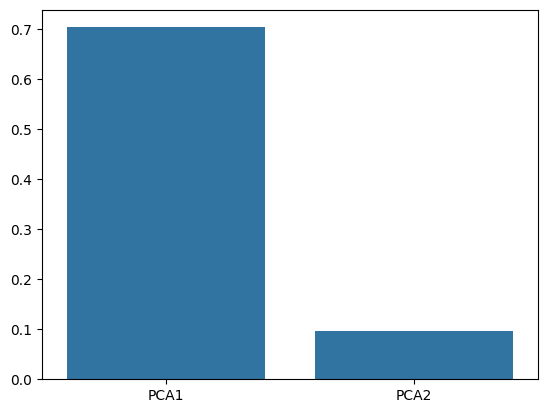

In [163]:
sns.barplot(x=['PCA1', 'PCA2'], y=pca_2.explained_variance_ratio_)

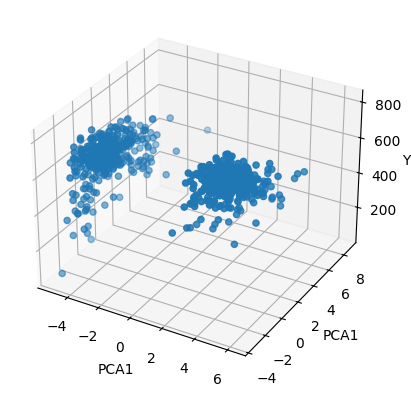

In [164]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = df_2['PCA1']
y = df_2['PCA2']
z = df_2['YDL']

ax.scatter(x,y,z)

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA1')
ax.set_zlabel('YDL')

plt.show()


## Seleccion de varaibles

In [165]:
pca_all = PCA(n_components=len(x_cols) , random_state=42)
df_pca_all = pca_all.fit_transform(df[x_cols])

df_pca_all[:4]
# pca_all.explained_variance_ratio_

array([[-3.73861933,  0.71823011, -0.21336391, -0.22200246, -0.22513579,
         0.41237016, -0.44262874, -0.06705009, -0.65447442, -0.20016748,
         0.01409222, -0.15728146, -0.09077236, -0.01267158, -0.17197167,
         0.08575105,  0.05362694,  0.17959298,  0.10596502,  0.11778912,
         0.03106525,  0.02567233],
       [-3.87060099, -0.53784429, -0.01787535,  0.14012973, -1.08831665,
         0.14943939, -0.07811854, -0.20786267, -0.24314265,  0.48636903,
        -0.28671703, -0.12388284,  0.15154673,  0.1333646 , -0.02435047,
        -0.05864199,  0.09713111,  0.06696057, -0.02834368, -0.06960982,
        -0.03329262, -0.0089747 ],
       [-3.64035113,  2.59593642, -0.8765809 , -0.144703  , -0.42132397,
        -0.25444942, -0.0146048 ,  0.83885231,  0.59901851,  0.05284245,
         0.16887606,  0.07120983, -0.10870862,  0.0767285 , -0.23856306,
        -0.02245938,  0.08945696,  0.13374219,  0.04558741,  0.05233553,
         0.01844598, -0.00579838],
       [-2.83699841

In [166]:
df_all = pd.DataFrame({
    "PCA1": df_pca_all[:,0],
    "PCA2": df_pca_all[:,1],
    "PCA3": df_pca_all[:,2],
    "PCA4": df_pca_all[:,3],
    "PCA5": df_pca_all[:,4],
    "PCA6": df_pca_all[:,5],
    "PCA7": df_pca_all[:,6],
    "PCA8": df_pca_all[:,7],
    "PCA9": df_pca_all[:,8],
    "PCA10": df_pca_all[:,9],
    "PCA11": df_pca_all[:,10],
    "PCA12": df_pca_all[:,11],
    "PCA13": df_pca_all[:,12],
    "PCA14": df_pca_all[:,13],
    "PCA15": df_pca_all[:,14],
    "PCA16": df_pca_all[:,15],
    "PCA17": df_pca_all[:,16],
    "PCA18": df_pca_all[:,17],
    "PCA19": df_pca_all[:,18],
    "PCA20": df_pca_all[:,19],
    "PCA21": df_pca_all[:,20],
    "PCA22": df_pca_all[:,21],
    "YDL": df[yield_col]})
df_all.head()


,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10,...,PCA14,PCA15,PCA16,PCA17,PCA18,PCA19,PCA20,PCA21,PCA22,YDL
0,-3.738619,0.718230,-0.213364,-0.222002,-0.225136,0.412370,-0.442629,-0.067050,-0.654474,-0.200167,...,-0.012672,-0.171972,0.085751,0.053627,0.179593,0.105965,0.117789,0.031065,0.025672,617.4453
1,-3.870601,-0.537844,-0.017875,0.140130,-1.088317,0.149439,-0.078119,-0.207863,-0.243143,0.486369,...,0.133365,-0.024350,-0.058642,0.097131,0.066961,-0.028344,-0.069610,-0.033293,-0.008975,689.6464
2,-3.640351,2.595936,-0.876581,-0.144703,-0.421324,-0.254449,-0.014605,0.838852,0.599019,0.052842,...,0.076728,-0.238563,-0.022459,0.089457,0.133742,0.045587,0.052336,0.018446,-0.005798,687.2559
3,-2.836998,5.461539,1.388336,-0.492821,-1.592636,-0.086806,0.035256,0.424434,-0.264041,-0.178000,...,0.109655,0.086674,0.223949,-0.061722,0.030628,-0.136963,-0.104621,0.056417,-0.036010,636.4969
4,-3.568021,0.674519,-0.286545,-0.391243,-0.065180,0.228831,-0.102663,-0.024181,0.085810,-0.221317,...,-0.088122,-0.060171,-0.047855,-0.170575,0.045167,-0.047163,-0.075750,0.041731,0.027759,616.5022


In [174]:
all_pca_col = []
for i in range(len(x_cols)):
    all_pca_col.append(f"PCA{i+1}")


<Axes: >

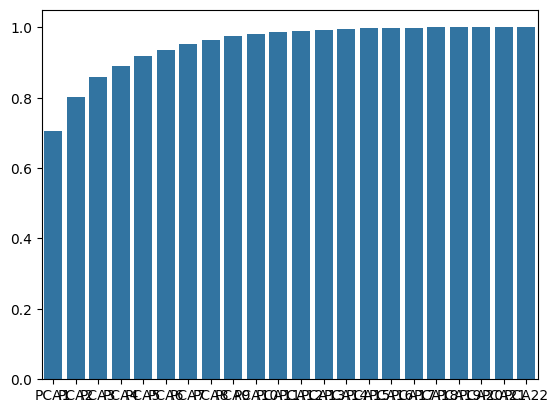

In [178]:
# print(len(pca_all.explained_variance_ratio_))
# pca_all.explained_variance_ratio_.size
# print(len(all_pca_col))
# all_pca_col

sns.barplot(x=all_pca_col, y=pca_all.explained_variance_ratio_.cumsum())